In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Payoff refers to profit in this context
def CalculateLongCallPayoff(stockPrice, strikePrice, premium):
    if(stockPrice < strikePrice):
        return -1 * premium
    else:
        return stockPrice - ( strikePrice + premium)
    
def CalculateLongPutPayoff(stockPrice, strikePrice, premium):
    if(stockPrice < strikePrice):
        return strikePrice - (stockPrice + premium)
    else:
        return -1 * premium
    
def CalculateShortCallPayoff(stockPrice, strikePrice, premium):
    if(stockPrice < strikePrice):
        return premium
    else:
        return premium + strikePrice - stockPrice
    
def CalculateShortPutPayoff(stockPrice, strikePrice, premium):
    if(stockPrice < strikePrice):
        return (stockPrice + premium) - strikePrice
    else:
        return premium

In [4]:
payoffs = pd.DataFrame(columns=['Stock Price', 'Long Call', 'Long Put', 'Short Call', 'Short Put'])

stockPrice = np.arange(1, 101)

payoffs['Stock Price'] = stockPrice
strikePrice = 50
premium = 10

payoffs['Long Call'] = payoffs['Stock Price'].apply(CalculateLongCallPayoff, args = (strikePrice, premium))
payoffs['Long Put'] = payoffs['Stock Price'].apply(CalculateLongPutPayoff, args = (strikePrice, premium))
payoffs['Short Call'] = payoffs['Stock Price'].apply(CalculateShortCallPayoff, args = (strikePrice, premium))
payoffs['Short Put'] = payoffs['Stock Price'].apply(CalculateShortPutPayoff, args = (strikePrice, premium))

payoffs

,Stock Price,Long Call,Long Put,Short Call,Short Put
0,1,-10,39,10,-39
1,2,-10,38,10,-38
2,3,-10,37,10,-37
3,4,-10,36,10,-36
4,5,-10,35,10,-35
...,...,...,...,...,...
95,96,36,-10,-36,10
96,97,37,-10,-37,10
97,98,38,-10,-38,10
98,99,39,-10,-39,10


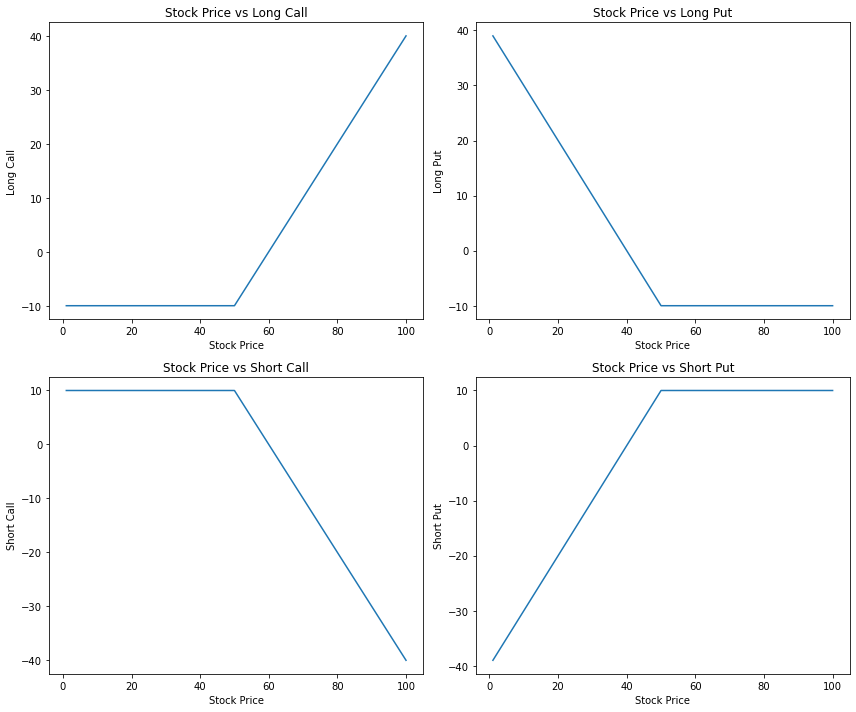

In [8]:
# plotting subgraphs
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()
y_columns = payoffs.columns[1:5]
x_column = payoffs.columns[0]

for i, y_col in enumerate(y_columns):
    ax = axes[i]
    ax.plot(payoffs[x_column], payoffs[y_col], label = y_col)
    ax.set_title(f'{x_column} vs {y_col}')
    ax.set_xlabel(x_column)
    ax.set_ylabel(y_col)

plt.tight_layout()
plt.show()

In [19]:
## covered call: long stock + short call, initial cost of stock being 40
initialCostOfStock = 40
payoffs['Covered Call'] = payoffs['Stock Price'].apply(CalculateShortCallPayoff, args = (strikePrice, premium)) + payoffs['Stock Price'] - initialCostOfStock

payoffs['Covered Call']

0    -29
1    -28
2    -27
3    -26
4    -25
      ..
95    20
96    20
97    20
98    20
99    20
Name: Covered Call, Length: 100, dtype: int64

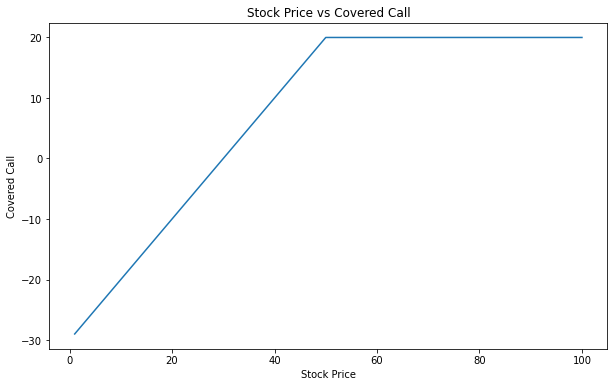

In [20]:
plt.figure(figsize = (10, 6))
plt.plot(payoffs['Stock Price'], payoffs['Covered Call'], label = payoffs['Covered Call'])
plt.title('Stock Price vs Covered Call')
plt.xlabel('Stock Price')
plt.ylabel('Covered Call')

plt.show()